In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
import contextily as ctx

The secondary schools have been filtered from the openstreetmap overpass API. Considerations were the name of the school and the ISCED number which is the UNESCO framework for categorising education systems and qualifications into standardised levels, ranging from level 0-8, where:
1. ISCED 0: Early childhood education.
2. ISCED 1: Primary education.
3. ISCED 2: Lower secondary education.
4. ISCED 3: Upper secondary education.
5. ISCED 4: Post-secondary non-tertiary education.
6. ISCED 5: Short-cycle tertiary education.
7. ISCED 6: Bachelor’s or equivalent level.
8. ISCED 7: Master’s or equivalent level.
9. ISCED 8: Doctoral or equivalent level.

The crime data on the otherhand was downloaded from the data.police.uk, from March 2023 to February 2026. This has been concatenated into one file. I will load the filtered datasets for this analysis.

In [2]:
# Load in the school data
sec_schools = pd.read_csv('bradford_secondary_schools.csv')

In [3]:
# Load crime data
crime_data = pd.read_csv('bradford_crime_data.csv')

ONS provides the UK boundary geometry for all LSOAs. See link for access:

https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2021-boundaries-ew-bsc-v4-2/about

In [4]:
# Load UK boundary
uk_boundary = gpd.read_file('boundary.geojson')

# Preprocessing

## Secondary schools

In [5]:
# View data
sec_schools.head()

,Unnamed: 0,osm_id,school_name,street_address,latitude,longitude,osm_type,isced_level,school_type
0,4,3954682148,Hazelbeck Special School,Wagon Lane,53.841401,-1.827540,node,2;3,NaN
1,7,12272261462,Dixons Trinity Academy,NaN,53.786414,-1.761281,node,2,secondary
2,13,27430004,Carlton Bolling,Undercliffe Lane,53.802248,-1.738203,way,2,secondary
3,14,27430869,Bradford Academy,Teasdale Street,53.776937,-1.732226,way,0;1;2;3,primary;secondary
4,15,27439679,Co-op Academy Grange,Haycliffe Lane,53.775439,-1.777453,way,2,secondary


In [6]:
# View shape
sec_schools.shape

(47, 9)

In [7]:
sec_schools.describe()

,Unnamed: 0,osm_id,latitude,longitude
count,47.000000,4.700000e+01,47.000000,47.000000
mean,120.638298,6.664055e+08,53.807310,-1.786391
std,69.837521,1.825183e+09,0.035010,0.052823
min,4.000000,2.743000e+07,53.742234,-1.925270
25%,71.500000,2.014329e+08,53.778931,-1.812631
50%,101.000000,3.897804e+08,53.802248,-1.777453
75%,187.500000,4.009674e+08,53.823577,-1.748027
max,231.000000,1.227226e+10,53.922108,-1.697207


In [8]:
# Check data features
sec_schools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      47 non-null     int64  
 1   osm_id          47 non-null     int64  
 2   school_name     47 non-null     object 
 3   street_address  46 non-null     object 
 4   latitude        47 non-null     float64
 5   longitude       47 non-null     float64
 6   osm_type        47 non-null     object 
 7   isced_level     46 non-null     object 
 8   school_type     31 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 3.4+ KB


## Crime data

In [9]:
# View data
crime_data.head()

,Unnamed: 0,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,0,c4e113322794b27396dd1c6c88ace5b01afaa363a54125...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.459649,53.605743,On or near Bleakley Lane,E01007438,Barnsley 001C,Drugs,Local resolution,NaN
1,1,NaN,2023-03,West Yorkshire Police,West Yorkshire Police,-1.906708,53.939023,On or near Turner Lane,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN
2,2,7c83c08291e705d2b53df1b4fd5b22d910e247c805b662...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.881027,53.943719,On or near Main Street,E01010646,Bradford 001A,Criminal damage and arson,Investigation complete; no suspect identified,NaN
3,3,e170228bffc479e50fd542f26444e19f9d04bcb74bfcd1...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,4,1b04ccf93c40b7da0d909094615d473685d00ca729f3bb...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN


In [10]:
# Check shape
crime_data.shape

(931689, 13)

In [11]:
# Check data features
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931689 entries, 0 to 931688
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             931689 non-null  int64  
 1   Crime ID               848329 non-null  object 
 2   Month                  931689 non-null  object 
 3   Reported by            931689 non-null  object 
 4   Falls within           931689 non-null  object 
 5   Longitude              921572 non-null  float64
 6   Latitude               921572 non-null  float64
 7   Location               931689 non-null  object 
 8   LSOA code              921572 non-null  object 
 9   LSOA name              921572 non-null  object 
 10  Crime type             931689 non-null  object 
 11  Last outcome category  848329 non-null  object 
 12  Context                0 non-null       float64
dtypes: float64(3), int64(1), object(9)
memory usage: 92.4+ MB


In [12]:
# more information on data
crime_data.describe()

,Unnamed: 0,Longitude,Latitude,Context
count,931689.000000,921572.000000,921572.000000,0.0
mean,465844.000000,-1.642881,53.758106,NaN
std,268955.591813,0.166764,0.070281,NaN
min,0.000000,-2.734806,52.586004,NaN
25%,232922.000000,-1.774705,53.704763,NaN
50%,465844.000000,-1.635107,53.775988,NaN
75%,698766.000000,-1.527830,53.807259,NaN
max,931688.000000,-0.278988,54.821894,NaN


## Bradford boundary

In [13]:
# View bradford
uk_boundary

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.09474 51.5206, -0.09546 51.51544,..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.0881 51.51941, -0.09546 51.51544,..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.09453 51.52205, -0.09274 51.52139..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.07589 51.5159, -0.07394 51.51445,..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.09328 51.53787, 0.09363 51.53767, ..."
...,...,...,...,...,...,...,...,...,...,...
35667,35668,W01002036,Vale of Glamorgan 005G,Bro Morgannwg 005G,317939,172435,51.44494,-3.182180,f79ed9c6-8220-49d9-9a69-e80e9f0007cb,"POLYGON ((-3.17711 51.44702, -3.17619 51.44261..."
35668,35669,W01002037,Vale of Glamorgan 005H,Bro Morgannwg 005H,318527,172406,51.44476,-3.173710,fdd8e9dc-8504-4955-aa8d-e4cff563ed76,"POLYGON ((-3.16647 51.44662, -3.1718 51.44303,..."
35669,35670,W01002038,Vale of Glamorgan 014G,Bro Morgannwg 014G,306491,167360,51.39754,-3.345520,7b56d7b1-48e6-4883-a46e-3bd00345bc8c,"POLYGON ((-3.34342 51.3898, -3.34926 51.38719,..."
35670,35671,W01002039,Vale of Glamorgan 014H,Bro Morgannwg 014H,306564,166023,51.38553,-3.344120,36d00276-9970-4f4b-9322-5b89fdacf0c3,"POLYGON ((-3.33578 51.38279, -3.33868 51.38189..."


In [14]:
# View shape of data
uk_boundary.shape

(35672, 10)

In [15]:
# Check data features
uk_boundary.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35672 entries, 0 to 35671
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   FID        35672 non-null  int32   
 1   LSOA21CD   35672 non-null  object  
 2   LSOA21NM   35672 non-null  object  
 3   LSOA21NMW  35672 non-null  object  
 4   BNG_E      35672 non-null  int32   
 5   BNG_N      35672 non-null  int32   
 6   LAT        35672 non-null  float64 
 7   LONG       35672 non-null  float64 
 8   GlobalID   35672 non-null  object  
 9   geometry   35672 non-null  geometry
dtypes: float64(2), geometry(1), int32(3), object(4)
memory usage: 2.3+ MB


In [16]:
# Check make up
uk_boundary.describe()

,FID,BNG_E,BNG_N,LAT,LONG
count,35672.000000,35672.000000,35672.000000,35672.000000,35672.000000
mean,17836.500000,446546.368384,273331.545554,52.348878,-1.324808
std,10297.763738,89372.181175,124715.053635,1.125584,1.295250
min,1.000000,91327.000000,11447.000000,49.923330,-6.302170
25%,8918.750000,386348.750000,176580.000000,51.476440,-2.203512
50%,17836.500000,443630.500000,246126.000000,52.098315,-1.353170
75%,26754.250000,522056.000000,385568.000000,53.364863,-0.232435
max,35672.000000,655206.000000,654392.000000,55.782840,1.757176


# Data cleaning

## Secondary school

In [17]:
# View secondary school data
sec_schools

,Unnamed: 0,osm_id,school_name,street_address,latitude,longitude,osm_type,isced_level,school_type
0,4,3954682148,Hazelbeck Special School,Wagon Lane,53.841401,-1.827540,node,2;3,NaN
1,7,12272261462,Dixons Trinity Academy,NaN,53.786414,-1.761281,node,2,secondary
2,13,27430004,Carlton Bolling,Undercliffe Lane,53.802248,-1.738203,way,2,secondary
3,14,27430869,Bradford Academy,Teasdale Street,53.776937,-1.732226,way,0;1;2;3,primary;secondary
4,15,27439679,Co-op Academy Grange,Haycliffe Lane,53.775439,-1.777453,way,2,secondary
5,36,51143176,Titus Salt School,Higher Coach Road,53.842914,-1.794062,way,2;3,secondary
6,37,51143343,Beckfoot School,Wagon Lane,53.840648,-1.828242,way,2;3,secondary
7,48,72765400,Jaamiatul Imaam Muhammad Zakaria,Thornton View Road,53.775754,-1.812779,way,2;3,NaN
8,56,144176269,Immanuel College,Leeds Road,53.842611,-1.726903,way,2;3,secondary
9,64,170627438,Ilkley Grammar School,Cowpasture Road,53.922108,-1.814690,way,2;3,secondary


In [18]:
# Drop the unnecessary columns
sec_schools = sec_schools.drop(['Unnamed: 0', 'osm_type', 'isced_level', 'street_address', 'school_type'], axis=1)

In [19]:
# Rename columns
# Create dictionary for the new names
school_cols = {'latitude': 'school_lat',
               'longitude': 'school_long'}

# Apply to the dataset
sec_schools = sec_schools.rename(columns=school_cols)

In [20]:
# Convert the geometries, latitude and longitude to point location of the school
sec_gdf = gpd.GeoDataFrame(
    sec_schools, geometry = gpd.points_from_xy(
        sec_schools['school_long'], sec_schools['school_lat'])
)

In [21]:
print(sec_gdf.crs)

None


In [22]:
# Set the CRS for school locations
sec_gdf = sec_gdf.set_crs(epsg=4326, inplace=True)

# Transform to British National Grid (Meters)
sec_gdf = sec_gdf.to_crs(epsg=27700)

## Bradford crime data

In [23]:
# Select bradford crime data from the West Yorkshire Police reports
bradford_crime = crime_data[
    crime_data['LSOA name'].str.contains(  # choose where bradford is contained in the LSOA name
        "bradford", case=False, na=False)]

# view the data
bradford_crime

,Unnamed: 0,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
1,1,NaN,2023-03,West Yorkshire Police,West Yorkshire Police,-1.906708,53.939023,On or near Turner Lane,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN
2,2,7c83c08291e705d2b53df1b4fd5b22d910e247c805b662...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.881027,53.943719,On or near Main Street,E01010646,Bradford 001A,Criminal damage and arson,Investigation complete; no suspect identified,NaN
3,3,e170228bffc479e50fd542f26444e19f9d04bcb74bfcd1...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,4,1b04ccf93c40b7da0d909094615d473685d00ca729f3bb...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
5,5,a633a2b1c1d0d203928611daf3dc06de0070f8ca2e38a0...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.878940,53.943744,On or near Cross End Fold,E01010646,Bradford 001A,Violence and sexual offences,Investigation complete; no suspect identified,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
915792,915792,dd1a7a84b4f1d414ab8bc2c202eb4408e0c2f3ab04ab83...,2026-02,West Yorkshire Police,West Yorkshire Police,-1.753689,53.794462,On or near Queensgate,E01033690,Bradford 065C,Other crime,Under investigation,NaN
915793,915793,0116ad60ec77d421827ed8fc3a3e498443620fdd0523db...,2026-02,West Yorkshire Police,West Yorkshire Police,-1.752028,53.793056,On or near Broadway,E01033690,Bradford 065C,Other crime,Awaiting court outcome,NaN
915794,915794,4d7d34c8c61c04d662d6735df5b7c6e8103ed1524cef54...,2026-02,West Yorkshire Police,West Yorkshire Police,-1.752341,53.791430,On or near Parking Area,E01033690,Bradford 065C,Other crime,Investigation complete; no suspect identified,NaN
915795,915795,121d8da15b86fbf29a96c9cb28bf599de2af36dcd38837...,2026-02,West Yorkshire Police,West Yorkshire Police,-1.750225,53.797546,On or near Mill Street,E01033690,Bradford 065C,Other crime,Under investigation,NaN


In [24]:
# Drop unuseful columns
bradford_crime = bradford_crime.drop(
    ['Unnamed: 0', 'Context', 'Last outcome category', 'Reported by', 'LSOA name','Falls within'], axis=1)

In [25]:
# View remaining columns
bradford_crime.columns

Index(['Crime ID', 'Month', 'Longitude', 'Latitude', 'Location', 'LSOA code',
       'Crime type'],
      dtype='object')

In [26]:
# Rename the columns
# Create dictionary for the column names
crime_cols = {'Crime ID': 'crime_id',
              'Month': 'month',
              'Longitude': 'crime_long',
              'Latitude':'crime_lat',
              'Location': 'crime_location',
              'LSOA code': 'lsoa_code',
              'Crime type':'crime_type'}

# Apply to the data
bradford_crime = bradford_crime.rename(columns=crime_cols)

In [27]:
# Convert the geometry to points
bradford_crime_gdf = gpd.GeoDataFrame(
    bradford_crime, geometry = gpd.points_from_xy(
        bradford_crime['crime_long'], bradford_crime['crime_lat'])
)

In [28]:
print(bradford_crime_gdf.crs)

None


In [29]:
# Set the initial CRS for crime locations
bradford_crime_gdf = bradford_crime_gdf.set_crs(epsg=4326, inplace=True)

# Transform to British National Grid (Meters)
bradford_crime_gdf = bradford_crime_gdf.to_crs(epsg=27700)

In [30]:
bradford_crime_gdf

,crime_id,month,crime_long,crime_lat,crime_location,lsoa_code,crime_type,geometry
1,NaN,2023-03,-1.906708,53.939023,On or near Turner Lane,E01010646,Anti-social behaviour,POINT (406221.983 449216.014)
2,7c83c08291e705d2b53df1b4fd5b22d910e247c805b662...,2023-03,-1.881027,53.943719,On or near Main Street,E01010646,Criminal damage and arson,POINT (407906.994 449741.022)
3,e170228bffc479e50fd542f26444e19f9d04bcb74bfcd1...,2023-03,-1.879954,53.945857,On or near Aynholme Close,E01010646,Violence and sexual offences,POINT (407977.024 449979.02)
4,1b04ccf93c40b7da0d909094615d473685d00ca729f3bb...,2023-03,-1.879954,53.945857,On or near Aynholme Close,E01010646,Violence and sexual offences,POINT (407977.024 449979.02)
5,a633a2b1c1d0d203928611daf3dc06de0070f8ca2e38a0...,2023-03,-1.878940,53.943744,On or near Cross End Fold,E01010646,Violence and sexual offences,POINT (408043.98 449744.035)
...,...,...,...,...,...,...,...,...
915792,dd1a7a84b4f1d414ab8bc2c202eb4408e0c2f3ab04ab83...,2026-02,-1.753689,53.794462,On or near Queensgate,E01033690,Other crime,POINT (416323.03 433156.043)
915793,0116ad60ec77d421827ed8fc3a3e498443620fdd0523db...,2026-02,-1.752028,53.793056,On or near Broadway,E01033690,Other crime,POINT (416432.992 432999.993)
915794,4d7d34c8c61c04d662d6735df5b7c6e8103ed1524cef54...,2026-02,-1.752341,53.791430,On or near Parking Area,E01033690,Other crime,POINT (416413.003 432819.013)
915795,121d8da15b86fbf29a96c9cb28bf599de2af36dcd38837...,2026-02,-1.750225,53.797546,On or near Mill Street,E01033690,Other crime,POINT (416550.011 433499.964)


## Bradford boundary

In [31]:
# View the data 
uk_boundary.head()

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.09474 51.5206, -0.09546 51.51544,..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.0881 51.51941, -0.09546 51.51544,..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.09453 51.52205, -0.09274 51.52139..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.07589 51.5159, -0.07394 51.51445,..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.09328 51.53787, 0.09363 51.53767, ..."


In [32]:
# Filter for bradford
bradford_boundary = uk_boundary[uk_boundary['LSOA21NM'].str.contains('Bradford', case=False, na=False)]

In [33]:
# Drop some other columns
bradford_boundary = bradford_boundary\
    .drop(['FID','LSOA21NMW', 'BNG_E',
           'BNG_N', 'GlobalID'], axis=1)

In [34]:
# Check remaining columns
bradford_boundary.columns

Index(['LSOA21CD', 'LSOA21NM', 'LAT', 'LONG', 'geometry'], dtype='object')

In [35]:
# Rename the columns
boundary_cols = {'WD25NM': 'ward',
                 'LONG': 'bound_long',
                 'LAT': 'bound_lat'}

# Apply to the boundary data
bradford_boundary = bradford_boundary.rename(columns=boundary_cols)

In [36]:
print(bradford_boundary.crs)

EPSG:4326


In [37]:
# Transform to British National Grid (Meters)
bradford_boundary = bradford_boundary.to_crs(epsg=27700)

# EDA

I will first check the dispersion of the schools around bradford.

In [38]:
# 'sjoin' merges the two based on their location
schools_with_lsoa = gpd.sjoin(sec_gdf, bradford_boundary, predicate='within')

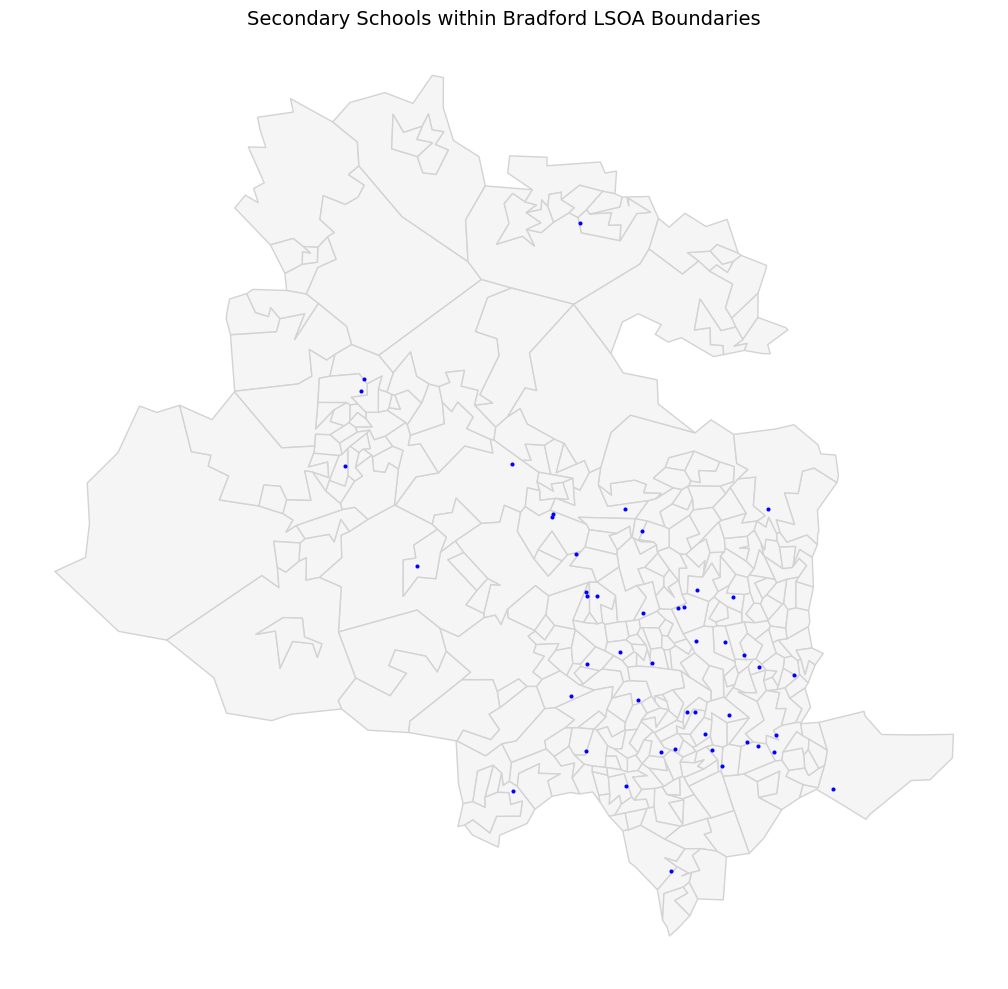

In [39]:
# Set chart layout
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the LSOA boundaries
bradford_boundary.plot(ax=ax, color='whitesmoke', edgecolor='lightgray')

# Plot the secondary schools on top
schools_with_lsoa.plot(ax=ax, color='blue', marker='.', markersize=15, label='Secondary Schools')

# Add title and remove axes
ax.set_title("Secondary Schools within Bradford LSOA Boundaries", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('secondary_schools_locations.png', dpi=300)
plt.show()

I will check the crime dispersion.

In [40]:
# Count crimes per LSOA
lsoa_crime_counts = bradford_crime_gdf.groupby('lsoa_code').size().reset_index(name='crime_count')

In [41]:
# Merge with Bradford boundary map
bradford_crime_count = bradford_boundary.merge(
    lsoa_crime_counts, left_on='LSOA21CD',
    right_on='lsoa_code', how='left')

In [42]:
bradford_crime_count

,LSOA21CD,LSOA21NM,bound_lat,bound_long,geometry,lsoa_code,crime_count
0,E01010568,Bradford 016A,53.84657,-1.75438,"POLYGON ((416587.768 439227.641, 416767.024 43...",E01010568,311
1,E01010569,Bradford 016B,53.84213,-1.77819,"POLYGON ((415417.077 439127.421, 415113.227 43...",E01010569,892
2,E01010570,Bradford 018A,53.84698,-1.78881,"POLYGON ((414616.587 438847.166, 414374.117 43...",E01010570,296
3,E01010571,Bradford 016C,53.84162,-1.77013,"POLYGON ((415762.764 438494.038, 415639.203 43...",E01010571,1198
4,E01010572,Bradford 016D,53.84574,-1.76700,"POLYGON ((415733.919 438844.777, 415580.786 43...",E01010572,164
...,...,...,...,...,...,...,...
307,E01033697,Bradford 049J,53.78535,-1.78917,"POLYGON ((414329.765 432222.698, 414148.345 43...",E01033697,1022
308,E01033898,Bradford 030E,53.81677,-1.80402,"POLYGON ((413361.151 435848.926, 413253.751 43...",E01033898,358
309,E01033899,Bradford 030F,53.81219,-1.81037,"POLYGON ((412808.1 434981.695, 412376.237 4350...",E01033899,413
310,E01033900,Bradford 044G,53.78965,-1.77738,"POLYGON ((414941.627 432585.14, 414582.068 432...",E01033900,225


In [43]:
# Calculate LSOA centroids
bradford_crime_count["x_centroid"] = bradford_crime_count.geometry.centroid.x
bradford_crime_count["y_centroid"] = bradford_crime_count.geometry.centroid.y

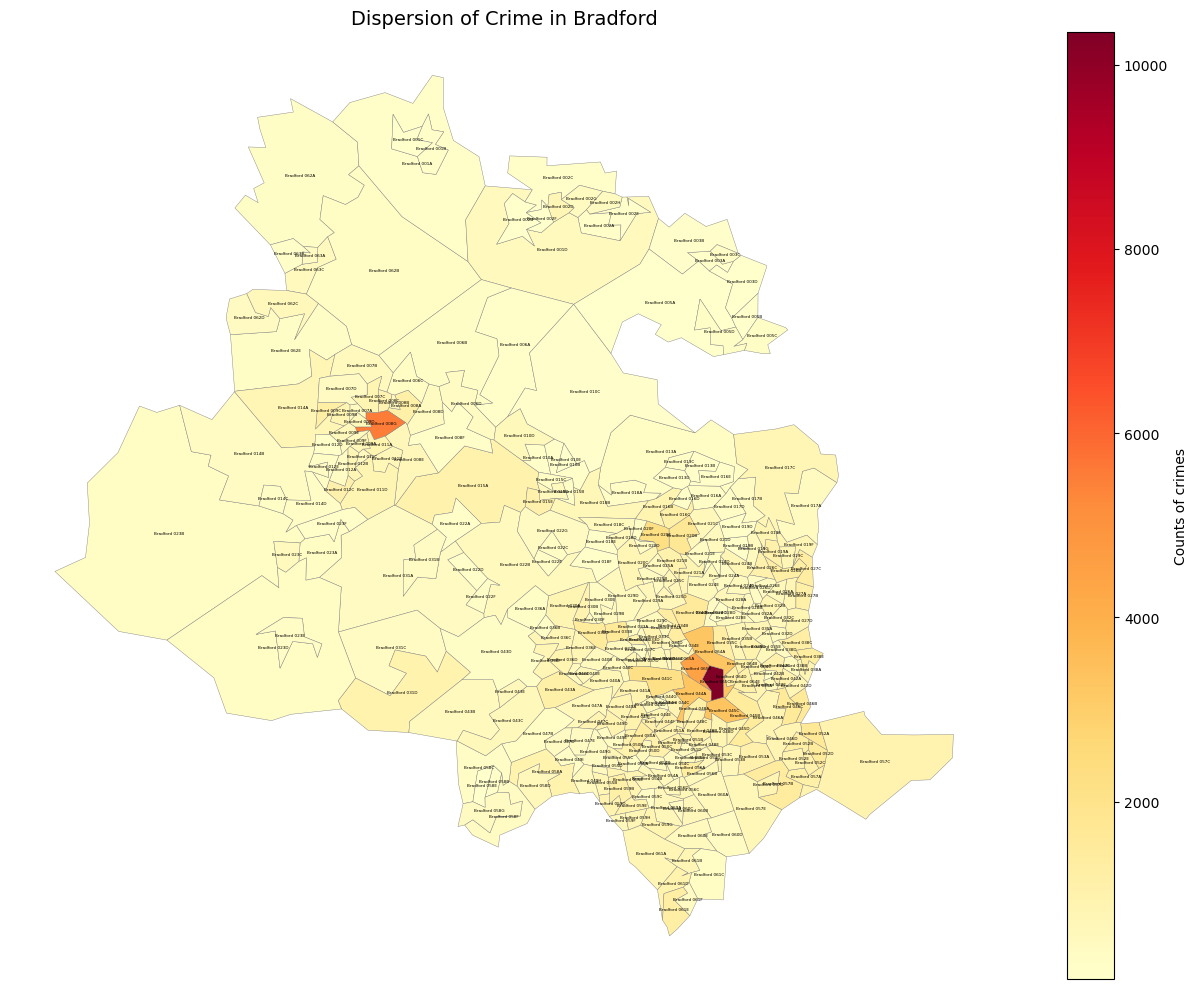

In [44]:
# Set chart layout
fig, ax = plt.subplots(figsize=(14, 10))

# Plot LSOAs shaded by crime count
bradford_crime_count.plot(
    column="crime_count", cmap='YlOrRd',
    edgecolor="grey", linewidth=0.3,
    legend=True, legend_kwds={'label': "Counts of crimes"},
    ax=ax)

# Add LSOA labels
for _, row in bradford_crime_count.iterrows():
    ax.text(row["x_centroid"], row["y_centroid"], row["LSOA21NM"],
            fontsize=3, ha="center", color="black")

ax.set_title("Dispersion of Crime in Bradford", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Dispersion of Crime in Bradford.png", dpi=300)
plt.show()

## Are secondary schools located in high-crime or low-crime LSOAs?

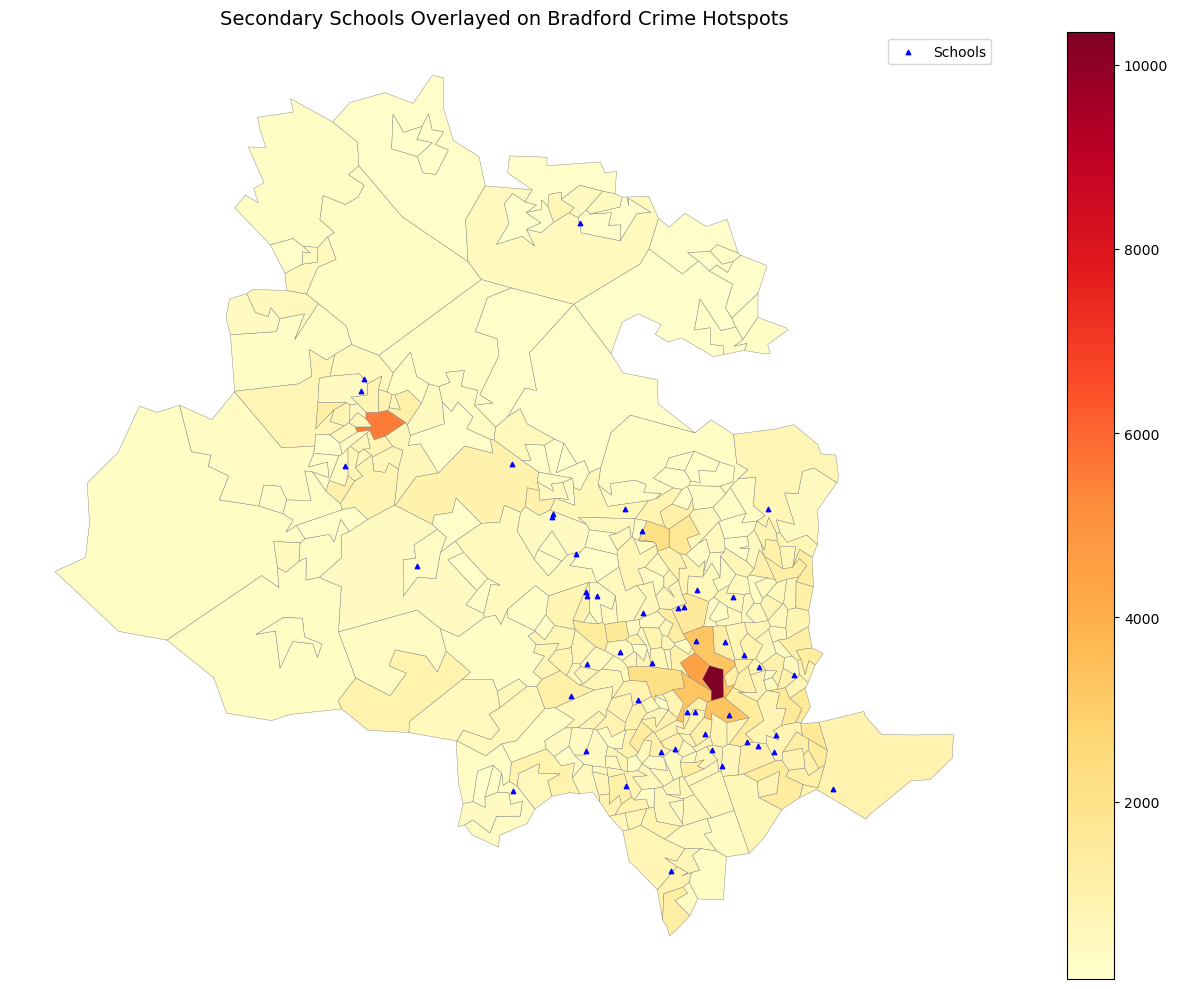

In [45]:
# Overlay school points on your crime map
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the base map
bradford_crime_count.plot(
    column='crime_count', cmap='YlOrRd', ax=ax,
    edgecolor='grey', linewidth=0.3, legend=True)

# Plot the schools on the same axis
sec_gdf.plot(
    ax=ax, color='blue', markersize=10, marker='^', label='Schools')

ax.set_title("Secondary Schools Overlayed on Bradford Crime Hotspots", fontsize=14)
ax.set_axis_off()
plt.legend()
plt.tight_layout()
plt.savefig('School locations and crime concentration.png', dpi=300)
plt.show()

Schools in the southern Bradford are located in areas were there are more reports of crime incidences. The proximity of these crimes to the schools can be looked at by exploring defined distances.

### Create buffer around school

My choice of buffer is discretionary, based on 6 minute proximity on foot to possible 30 minute on commercial buses.

In [46]:
# Define buffer distances in meters
buffer_distances = [500, 1000, 1500, 2000, 2500, 3000, 3500]

In [47]:
# Set buffers around the school locations
# Create empty list
buffers = []

# Loop the distances for each school
for distance in buffer_distances:
    school = sec_gdf.copy() # Copy the school data
    school["geometry"] = sec_gdf.buffer(distance)  # set buffer around school geometry
    school["buffer_distance"] = distance  # Specify buffer distance
    buffers.append(school) # Append the different buffer distances

In [48]:
# Concat the data
school_buff_df = pd.concat(buffers, ignore_index=True)
school_buff_df

,osm_id,school_name,school_lat,school_long,geometry,buffer_distance
0,3954682148,Hazelbeck Special School,53.841401,-1.827540,"POLYGON ((411945.506 438364.193, 411943.098 43...",500
1,12272261462,Dixons Trinity Academy,53.786414,-1.761281,"POLYGON ((416325.903 432258.898, 416323.496 43...",500
2,27430004,Carlton Bolling,53.802248,-1.738203,"POLYGON ((417839.941 434025.902, 417837.533 43...",500
3,27430869,Bradford Academy,53.776937,-1.732226,"POLYGON ((418244.204 431211.335, 418241.796 43...",500
4,27439679,Co-op Academy Grange,53.775439,-1.777453,"POLYGON ((415264.223 431034.38, 415261.815 430...",500
...,...,...,...,...,...,...
324,418371917,Oasis Academy Lister Park,53.815464,-1.766240,"POLYGON ((418988.556 435489.976, 418971.703 43...",3500
325,463478292,Prism Independent School,53.800157,-1.781504,"POLYGON ((417988.776 433783.644, 417971.923 43...",3500
326,464219422,Bradford Forster Academy,53.779903,-1.723678,"POLYGON ((421806.264 431543.452, 421789.411 43...",3500
327,1322905101,Bronte Girls' Secondary Academy,53.785564,-1.745519,"POLYGON ((420364.743 432167.918, 420347.89 431...",3500


In [49]:
# Spatial join the crime dataset and school to find crimes within buffers
schools_and_crimes = gpd.sjoin(bradford_crime_gdf, school_buff_df, predicate='within')

Group by both to see the trend of crime as the radius expands

In [50]:
# Aggregate crimes per school and per distance
crime_analysis = schools_and_crimes.groupby(
    ['school_name', 'buffer_distance']).size().reset_index(name='crime_count')

In [51]:
crime_analysis.head(3)

,school_name,buffer_distance,crime_count
0,Al Mumin Primary and Secondary School,500,2033
1,Al Mumin Primary and Secondary School,1000,9322
2,Al Mumin Primary and Secondary School,1500,27492


In [52]:
# Change to pivot table
crime_analysis_pivot = crime_analysis.pivot(
    index='school_name', columns='buffer_distance',
    values='crime_count')

In [53]:
crime_analysis_pivot

buffer_distance,500,1000,1500,2000,2500,3000,3500
school_name,,,,,,,
Al Mumin Primary and Secondary School,2033,9322,27492,46661,65119,84154,108647
Appleton Academy,965,3469,5155,7283,10918,15272,20259
Beckfoot Oakbank,1166,5469,9178,17595,21045,23544,24882
Beckfoot School,274,2401,4451,5481,7625,11268,16319
Beckfoot Thornton,297,4401,9041,14441,26732,38934,51277
Beckfoot Upper Heaton,1191,3112,6292,12803,21867,34635,45289
Belle Vue Girls' Academy,856,2694,5849,11180,20253,34431,45296
Bingley Grammar School,338,1374,3228,4219,4985,6016,8053
Bradford Academy,1370,5686,12917,28703,52779,69267,85148


In [54]:
# Sort the entire pivot table by the 3500m distance
crime_analysis_pivot = crime_analysis_pivot.sort_values(by=3500, ascending=False)

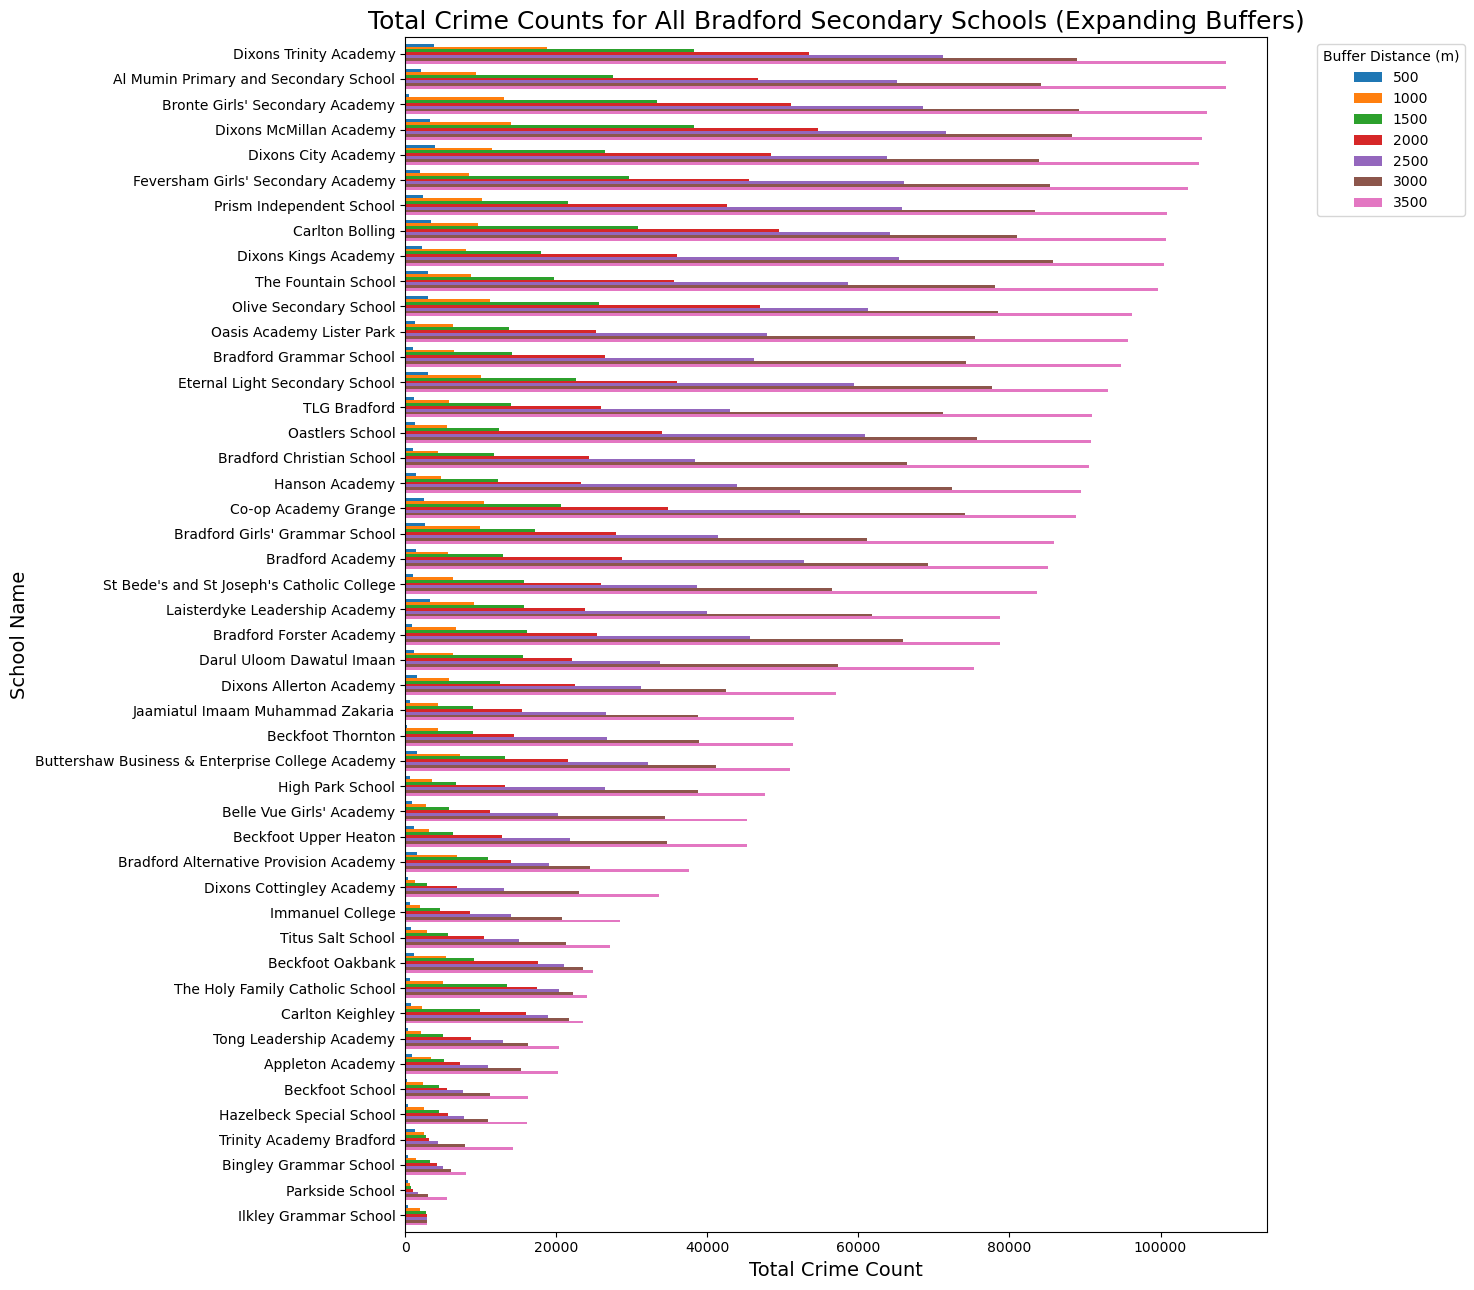

In [55]:
# Set plot layout
fig, ax = plt.subplots(figsize=(15, 13))

# Plot all schools
crime_analysis_pivot.plot(kind='barh', width=0.8, ax=ax)

# Customise labels
plt.title("Total Crime Counts for All Bradford Secondary Schools (Expanding Buffers)", fontsize=18)
plt.xlabel("Total Crime Count", fontsize=14)
plt.ylabel("School Name", fontsize=14)

# Invert Y-axis so the highest crime school is at the top
plt.gca().invert_yaxis()

# Adjust the legend
plt.legend(title="Buffer Distance (m)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Top 10 chart could be better. But let me count crimes according to schools.

In [56]:
# Count crimes by school within buffer distances
crimes_by_school = schools_and_crimes.groupby(
    ['school_name', 'crime_type', 'buffer_distance']).size().reset_index(name='crime_count')

crimes_by_school

,school_name,crime_type,buffer_distance,crime_count
0,Al Mumin Primary and Secondary School,Anti-social behaviour,500,104
1,Al Mumin Primary and Secondary School,Anti-social behaviour,1000,712
2,Al Mumin Primary and Secondary School,Anti-social behaviour,1500,2061
3,Al Mumin Primary and Secondary School,Anti-social behaviour,2000,3606
4,Al Mumin Primary and Secondary School,Anti-social behaviour,2500,4798
...,...,...,...,...
4581,Trinity Academy Bradford,Violence and sexual offences,1500,1246
4582,Trinity Academy Bradford,Violence and sexual offences,2000,1423
4583,Trinity Academy Bradford,Violence and sexual offences,2500,2061
4584,Trinity Academy Bradford,Violence and sexual offences,3000,3686


In [57]:
crimes_by_school_pivot = crimes_by_school.pivot_table(
    index='school_name',
    columns=['buffer_distance', 'crime_type'],
    values='crime_count'
).fillna(0)

crimes_by_school_pivot

buffer_distance                                                   500   \
crime_type                                       Anti-social behaviour   
school_name                                                              
Al Mumin Primary and Secondary School                            104.0   
Appleton Academy                                                  90.0   
Beckfoot Oakbank                                                 106.0   
Beckfoot School                                                   31.0   
Beckfoot Thornton                                                 30.0   
Beckfoot Upper Heaton                                             69.0   
Belle Vue Girls' Academy                                          46.0   
Bingley Grammar School                                            39.0   
Bradford Academy                                                 142.0   
Bradford Alternative Provision Academy                           150.0   
Bradford Christian School                                        141.0   
Bradford Forster Academy                                          29.0   
Bradford Girls' Grammar School                                   120.0   
Bradford Grammar School                                           91.0   
Bronte Girls' Secondary Academy                                   20.0   
Buttershaw Business & Enterprise College Academy                  88.0   
Carlton Bolling                                                  379.0   
Carlton Keighley                                                  69.0   
Co-op Academy Grange                                             134.0   
Darul Uloom Dawatul Imaan                                         57.0   
Dixons Allerton Academy                                          141.0   
Dixons City Academy                                              310.0   
Dixons Cottingley Academy                                         27.0   
Dixons Kings Academy                                             234.0   
Dixons McMillan Academy                                          197.0   
Dixons Trinity Academy                                           229.0   
Eternal Light Secondary School                                   195.0   
Feversham Girls' Secondary Academy                               253.0   
Hanson Academy                                                   137.0   
Hazelbeck Special School                                          44.0   
High Park School                                                  26.0   
Ilkley Grammar School                                             33.0   
Immanuel College                                                  83.0   
Jaamiatul Imaam Muhammad Zakaria                                  45.0   
Laisterdyke Leadership Academy                                   251.0   
Oasis Academy Lister Park                                        105.0   
Oastlers School                                                  165.0   
Olive Secondary School                                           307.0   
Parkside School                                                   17.0   
Prism Independent School                                         119.0   
St Bede's and St Joseph's Catholic College                        81.0   
TLG Bradford                                                     111.0   
The Fountain School                                              220.0   
The Holy Family Catholic School                                   66.0   
Titus Salt School                                                194.0   
Tong Leadership Academy                                           26.0   
Trinity Academy Bradford                                         147.0   

buffer_distance                                                          \
crime_type                                       Bicycle theft Burglary   
school_name                                                               
Al Mumin Primary and Secondary School                     11.0     53.0   

Violence and sexual offences tops the list of crimes in Bradford, followed by crimes on public order, anti-social behaviour, and criminal damage and arson.

In [58]:
# Select 500 meter buffer
buff_500m = crimes_by_school[crimes_by_school['buffer_distance'] == 500]

# Pivot the crime
buff_500m_pivot = buff_500m.pivot_table(
    index='school_name',
    columns='crime_type',
    values='crime_count'
).fillna(0)

buff_500m_pivot

crime_type,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
school_name,,,,,,,,,,,,,,
Al Mumin Primary and Secondary School,104.0,11.0,53.0,155.0,99.0,68.0,163.0,21.0,196.0,22.0,61.0,12.0,93.0,975.0
Appleton Academy,90.0,6.0,77.0,61.0,26.0,43.0,59.0,12.0,65.0,4.0,13.0,5.0,64.0,440.0
Beckfoot Oakbank,106.0,2.0,51.0,73.0,21.0,50.0,37.0,14.0,89.0,3.0,8.0,7.0,40.0,665.0
Beckfoot School,31.0,2.0,26.0,22.0,13.0,8.0,16.0,1.0,35.0,2.0,0.0,0.0,20.0,98.0
Beckfoot Thornton,30.0,1.0,5.0,16.0,5.0,28.0,8.0,6.0,32.0,4.0,0.0,0.0,13.0,149.0
Beckfoot Upper Heaton,69.0,2.0,40.0,68.0,34.0,35.0,68.0,12.0,100.0,9.0,25.0,9.0,33.0,687.0
Belle Vue Girls' Academy,46.0,1.0,22.0,53.0,20.0,29.0,52.0,4.0,62.0,6.0,25.0,8.0,23.0,505.0
Bingley Grammar School,39.0,2.0,21.0,18.0,3.0,5.0,24.0,3.0,29.0,3.0,55.0,0.0,18.0,118.0
Bradford Academy,142.0,10.0,86.0,86.0,55.0,96.0,61.0,14.0,117.0,12.0,20.0,2.0,76.0,593.0


Anti-social behaviours are more prevalent within 500 meters of Carlton Bolling, Dixons City Academy, and Olive Secondary School. Dixons McMillan, Trinity, and City Academies are the top three with prevalence of bicycle theft, burglary, drugs, other theft. Criminal damage and arson and violence and sexual offences happen more within the 500 meters radius of Carlton Bolling, Dixons City and Trinity Academies.

Carlton Bolling, Laisterdyke Leadership Academy, Darrul Uloom Dawatul Imaan are prevalent with other crime within 1000 meters. Possession of weapons is prevalent within 500 meters of Dixons Trinity Academy, The Fountain School, and Co-op Academy Grange

## Visualisation

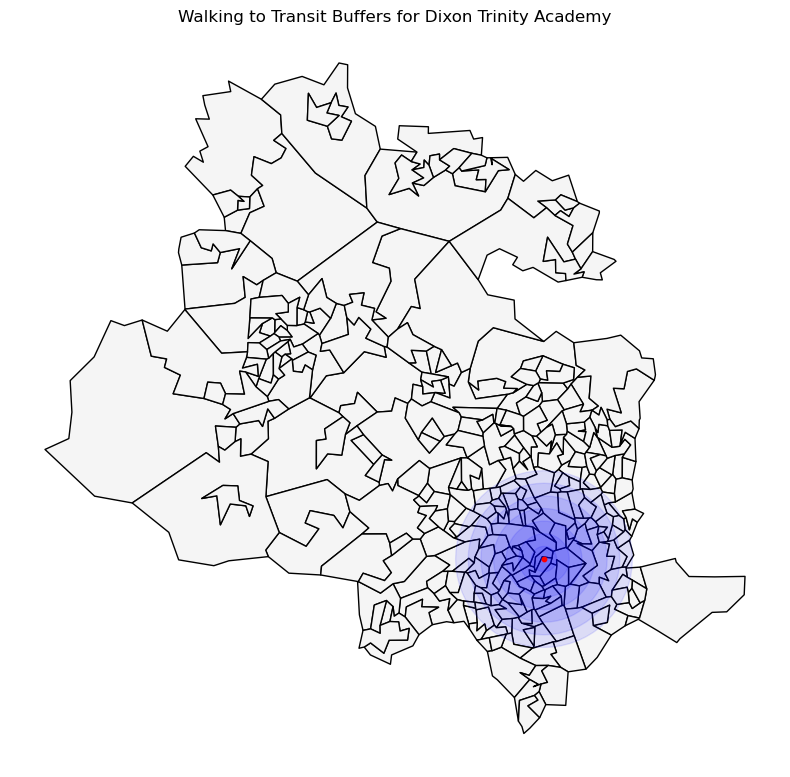

In [59]:
# Pick one school to show the "bullseye" effect
dt_academy = school_buff_df[school_buff_df['school_name'] == 'Dixons Trinity Academy']

fig, ax = plt.subplots(figsize=(8, 8))
bradford_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black')

# Plot buffers with transparency (alpha) so you can see the overlap
dt_academy.plot(ax=ax, color='blue', alpha=0.1, edgecolor='blue')
sec_gdf[sec_gdf['school_name'] == 'Dixons Trinity Academy'].plot(ax=ax, color='red', markersize=10)

plt.title("Walking to Transit Buffers for Dixon Trinity Academy")
ax.set_axis_off()
plt.tight_layout()
plt.show()

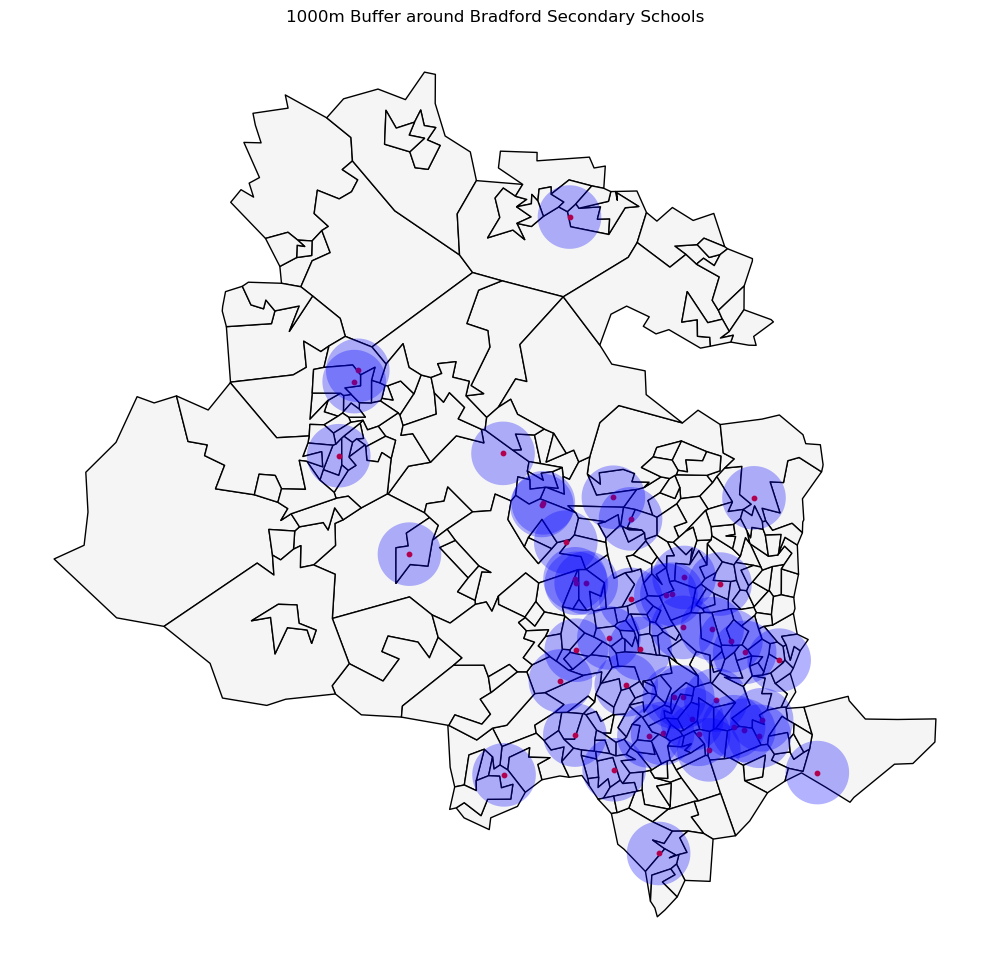

In [60]:
# Plot only the 1000m 'walking' buffer for all schools
dist_1000 = school_buff_df[school_buff_df['buffer_distance'] == 1000]

fig, ax = plt.subplots(figsize=(10, 10))
bradford_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black')
sec_gdf.plot(ax=ax, color='red', markersize=10)
dist_1000.plot(ax=ax, color='blue', alpha=0.3)
plt.title("1000m Buffer around Bradford Secondary Schools")
ax.set_axis_off()
plt.tight_layout()
plt.savefig('1000m Buffer around Bradford Secondary Schools.png', dpi=300)
plt.show()

Visualise all the buffer distances for comparison

In [61]:
# Setup the grid
n_dist = school_buff_df['buffer_distance'].nunique()
buffer_distances = school_buff_df['buffer_distance'].unique()

ncols = 2
nrows = math.ceil(n_dist / ncols)

In [62]:
school_buff_df.columns

Index(['osm_id', 'school_name', 'school_lat', 'school_long', 'geometry',
       'buffer_distance'],
      dtype='object')

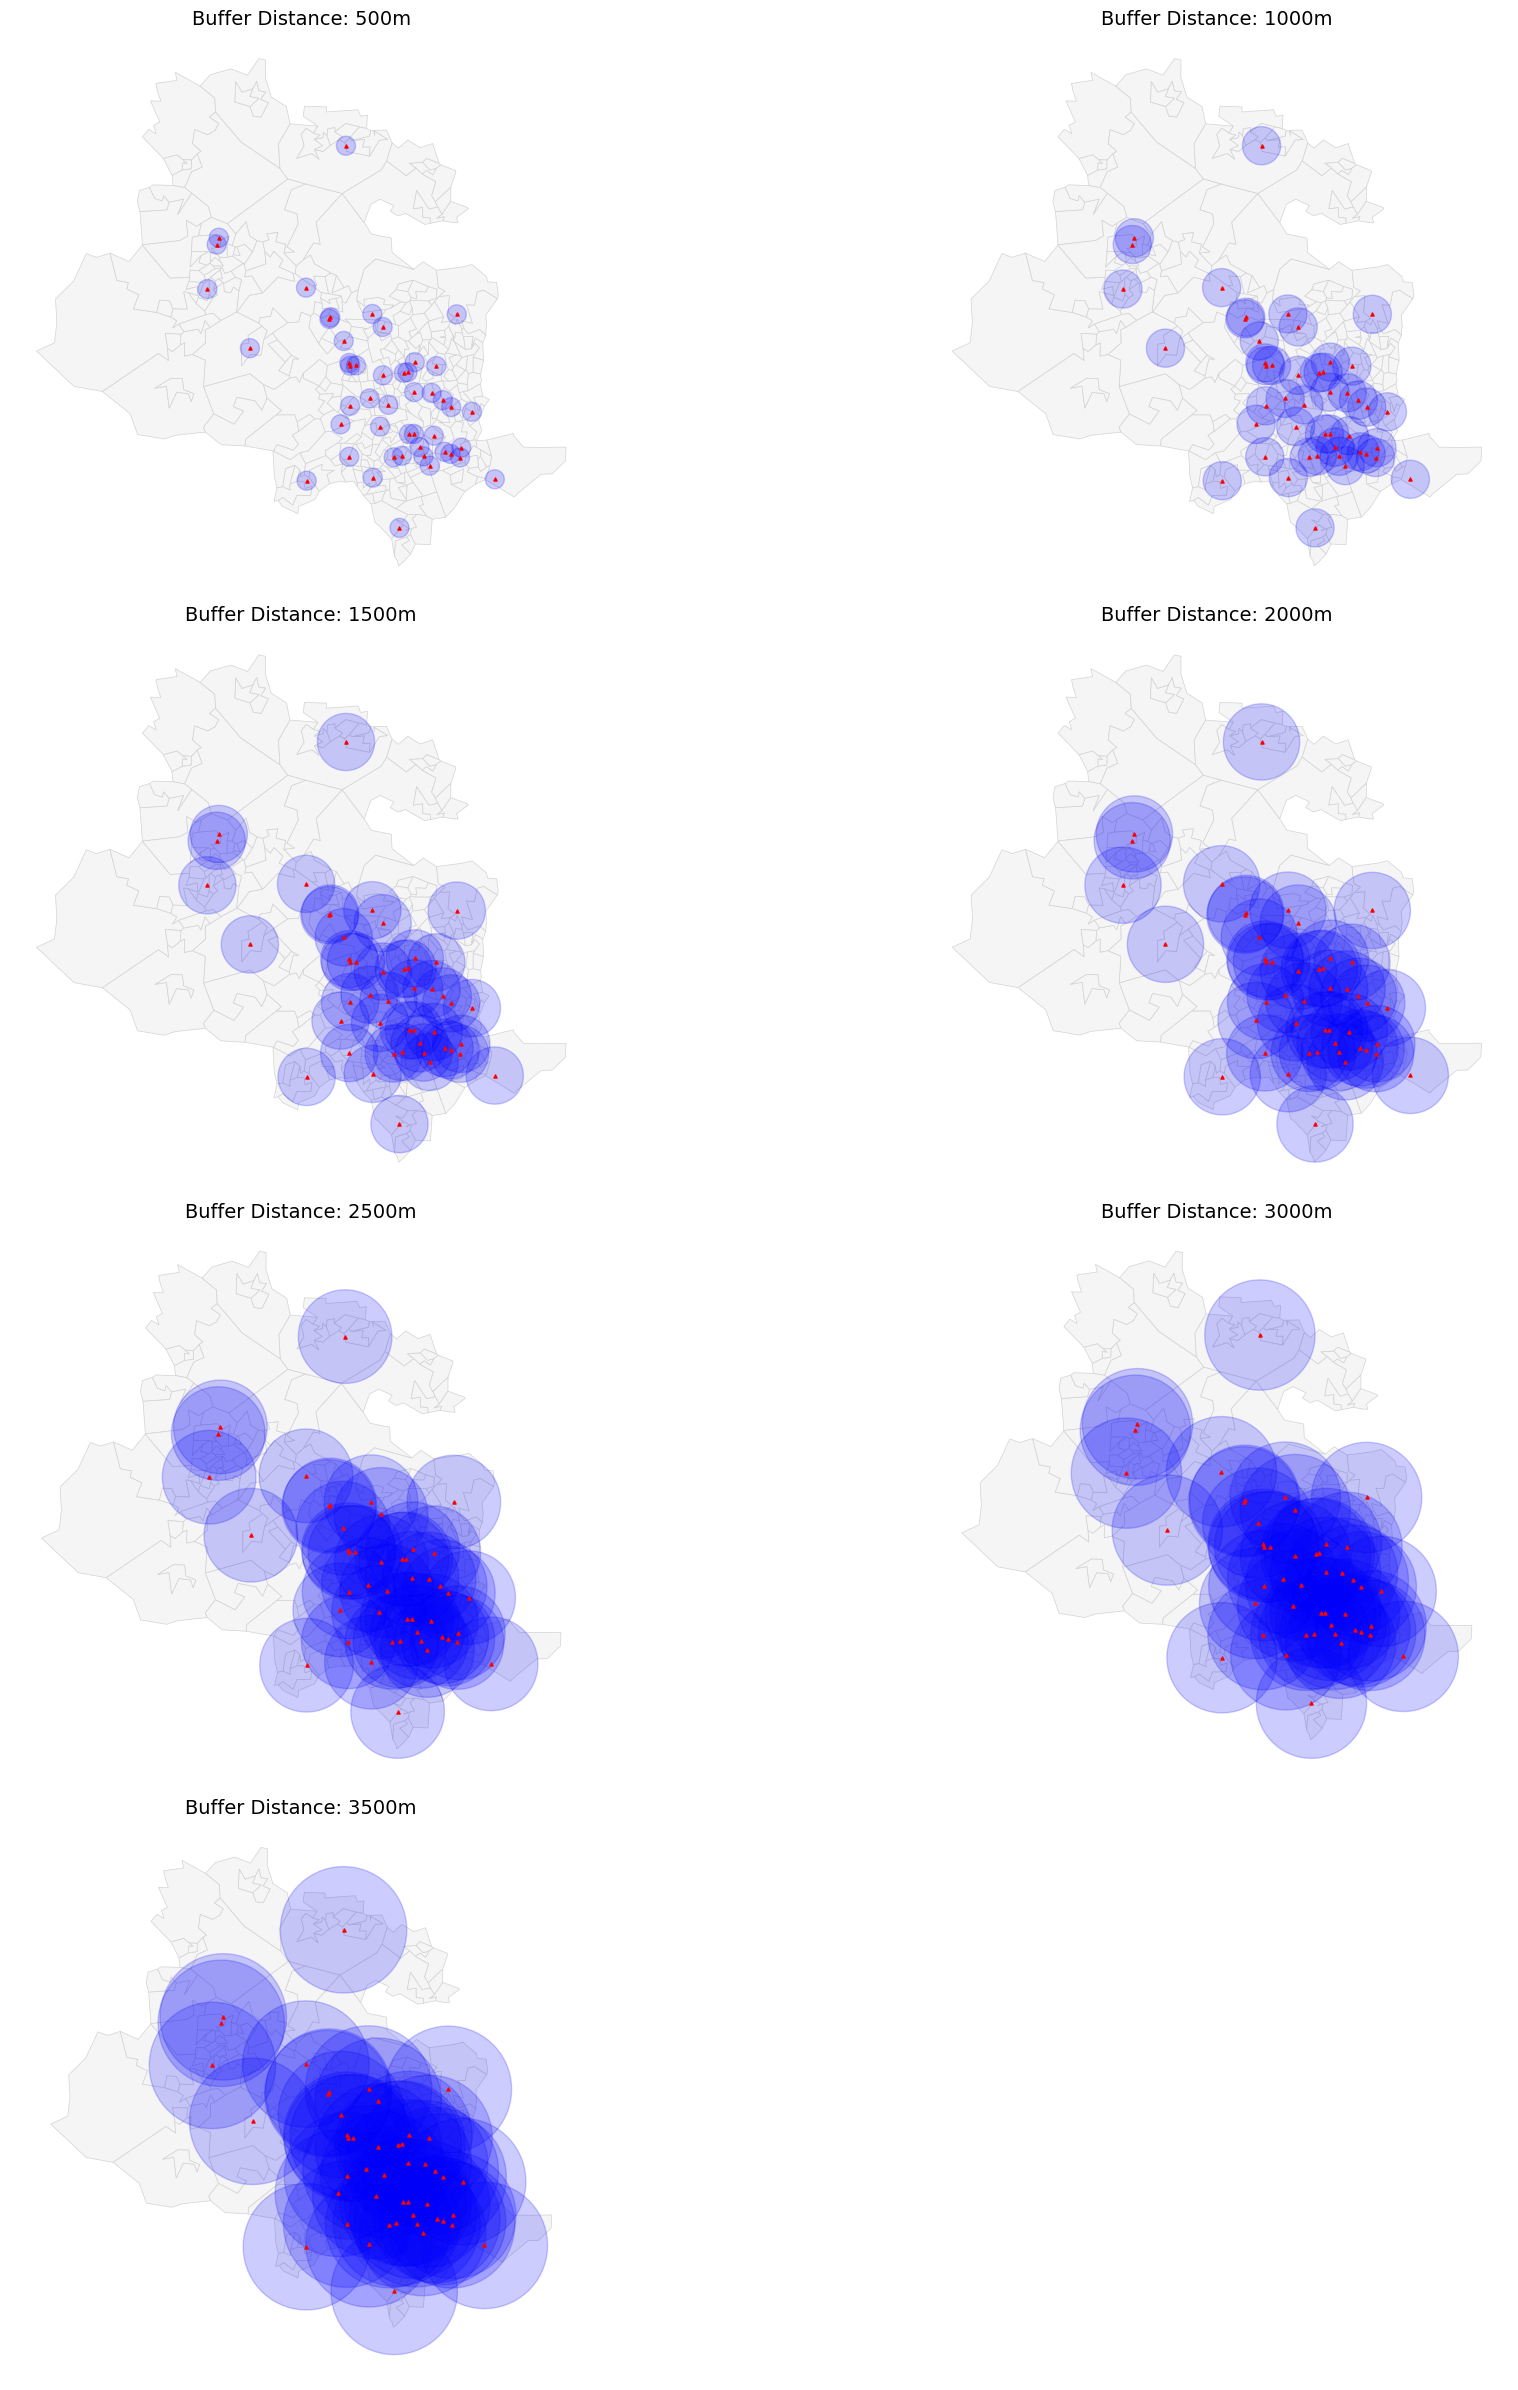

In [63]:
# Set the plot layout 
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 6))
axes = axes.flatten() # Flatten to 1D so we can for easy looping

# Loop through each distance and create a subplot
for i, dist in enumerate(buffer_distances):
    ax = axes[i]
    
    # Plot the Bradford base map
    bradford_boundary.plot(ax=ax, color='whitesmoke', edgecolor='lightgray', linewidth=0.5)
    
    # Filter buffers for this specific distance
    current_buffers = school_buff_df[school_buff_df['buffer_distance'] == dist]
    
    # Plot the buffers with transparency
    current_buffers.plot(ax=ax, color='blue', alpha=0.2, edgecolor='blue', linewidth=1)
    
    # Plot the school center points
    sec_gdf.plot(ax=ax, color='red', markersize=5, marker='^')
    
    ax.set_title(f"Buffer Distance: {dist}m", fontsize=14)
    ax.set_axis_off() # Clean up by removing lat/long axes

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('buffer_distances.png', dpi=300)
plt.show()

## Are the neighborhoods around schools hotspots for crime?

This requires understanding the crime density for the neighborhoods around the schools. Crime density is the concentration of crime within an area. This will involve comparing crime inside the buffer to crime outside the buffer in the same school location. If crime inside is significantly higher than the surrounding neighbourhood, that is evidence of elevated risk.

Crime density = count of crimes within a buffer divided by the area of the buffer in (sq km).

The Area of a circle = pi * r^2

Distance conversion factors:\
1000 meter = 1 kilometers\
1000000 meter sq = 1 kilometers sq

In [64]:
# Reset index
density_df = crime_analysis_pivot.copy()

The buffer distance is the radius of the circular buffer circumference.

In [65]:
# Get considered distances
radii = list(density_df.columns)
radii

[500, 1000, 1500, 2000, 2500, 3000, 3500]

In [66]:
# Compute the density for each distance
for radius in radii:
    area = (np.pi * (radius**2))   # Calculate the area
    area_km2 = area / 1000000 # Convert distances to sq km by dividing by 1,000,000 to get km2
    density_df[f'density_{radius}m'] = density_df[radius] / area_km2  # Calculate the density

In [67]:
density_df

buffer_distance,500,1000,1500,2000,2500,3000,3500,density_500m,density_1000m,density_1500m,density_2000m,density_2500m,density_3000m,density_3500m
school_name,,,,,,,,,,,,,,
Dixons Trinity Academy,3807,18762,38227,53465,71154,88971,108698,4847.222947,5972.130085,5408.014231,4254.609516,3623.843463,3146.705432,2824.461062
Al Mumin Primary and Secondary School,2033,9322,27492,46661,65119,84154,108647,2588.495994,2967.284759,3889.322396,3713.164400,3316.483437,2976.338907,2823.135853
Bronte Girls' Secondary Academy,507,13099,33380,51069,68511,89185,106168,645.532449,4169.541199,4722.304000,4063.941894,3489.236578,3154.274133,2758.720326
Dixons McMillan Academy,3287,14020,38273,54599,71609,88265,105434,4185.138384,4462.704604,5414.521900,4344.850369,3647.016422,3121.735789,2739.647718
Dixons City Academy,3917,11512,26429,48487,63759,83868,105112,4987.279297,3664.383410,3738.938659,3858.472863,3247.219205,2966.223726,2731.280715
Feversham Girls' Secondary Academy,1926,8489,29655,45474,66090,85371,103625,2452.259363,2702.132624,4195.324300,3618.705941,3365.936060,3019.381477,2692.641792
Prism Independent School,2305,10129,21600,42598,65781,83359,100799,2934.817151,3224.160837,3055.774907,3389.841133,3350.198820,2948.221534,2619.209650
Carlton Bolling,3443,9648,30875,49462,64198,81038,100716,4383.763753,3071.053782,4367.918994,3936.060898,3269.577292,2866.132951,2617.052939
Dixons Kings Academy,2255,8062,17960,35973,65363,85823,100406,2871.155173,2566.214302,2540.820247,2862.640384,3328.910255,3035.367707,2608.997750


## Compare raw counts and density within 500 meter distance

In [68]:
# Define column groups
count_cols = [500, 1000, 1500, 2000, 2500, 3000, 3500]
density_cols = [f'density_{d}m' for d in count_cols]

In [69]:
# Compare the top 10
# Select schools by density
plot_df = density_df.nlargest(10, 'density_500m')

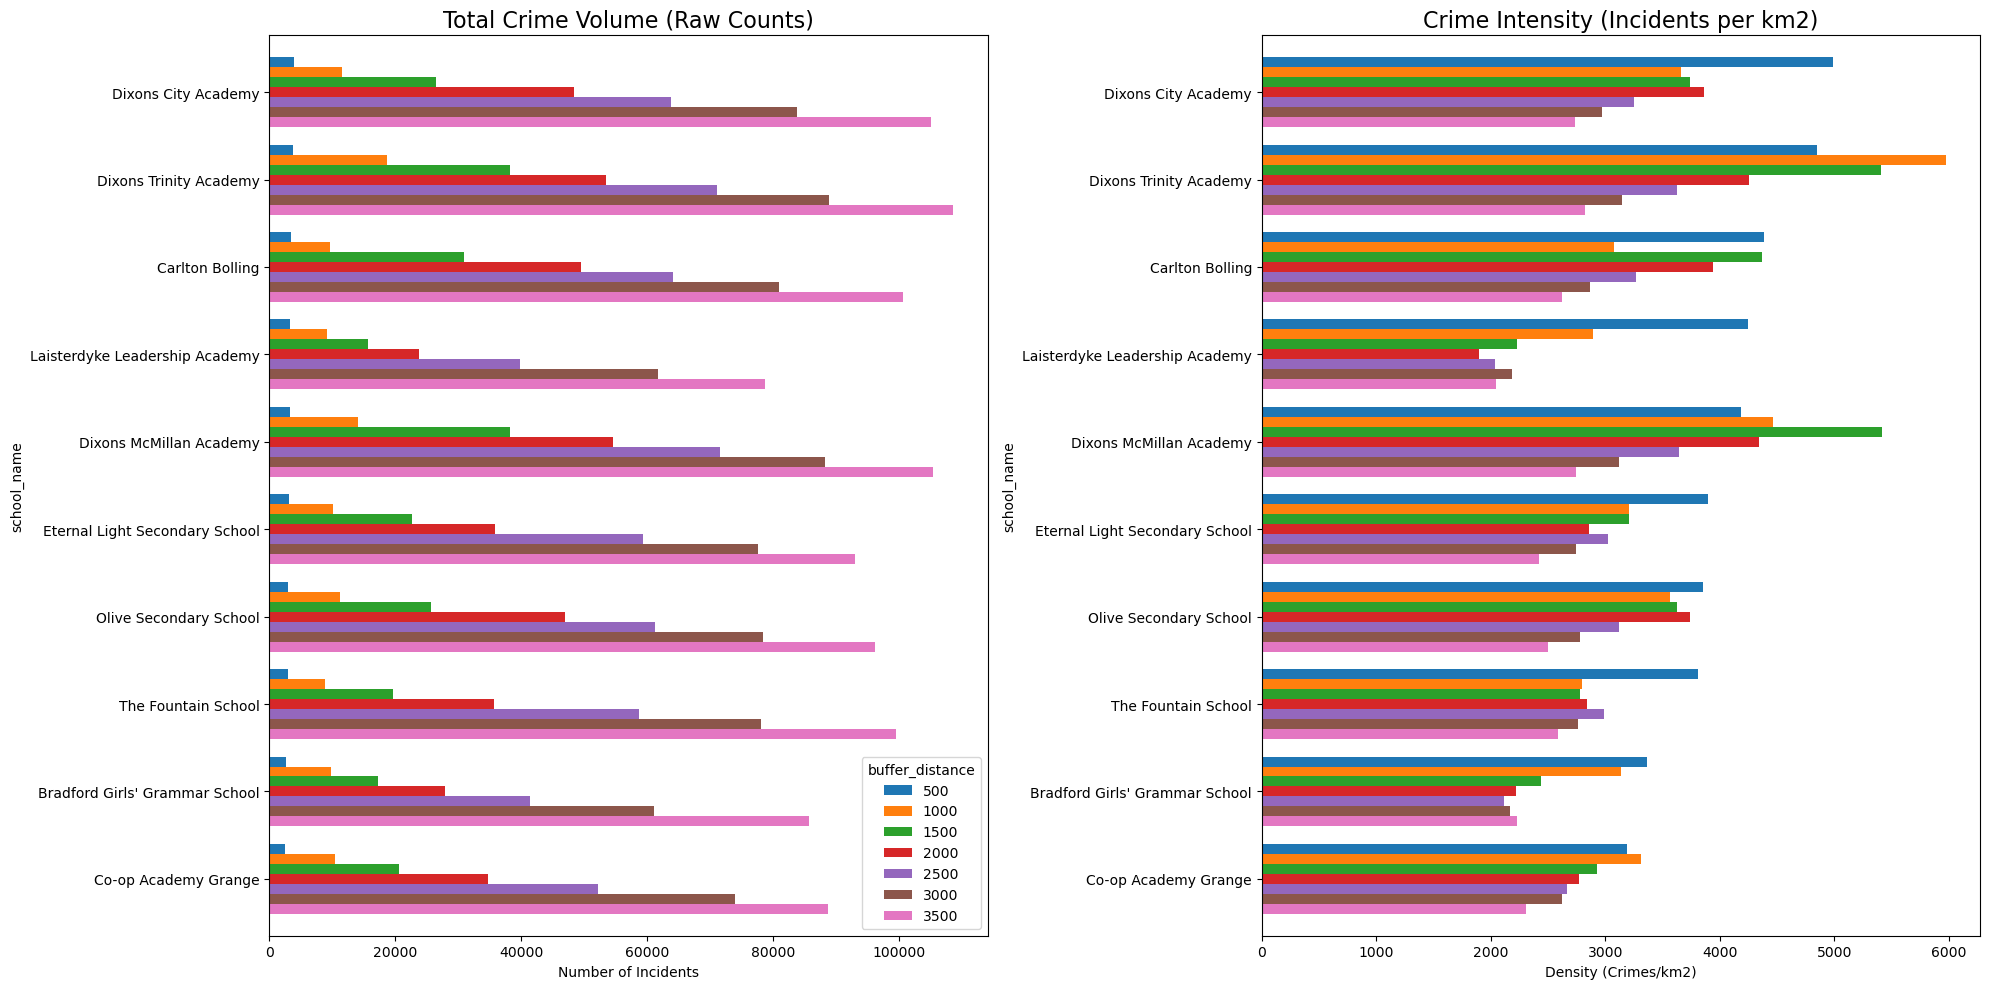

In [70]:
# Create the Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharey=False)

# Chart 1: Raw Crime Counts
plot_df[count_cols].plot(kind='barh', ax=ax1, width=0.8)
ax1.set_title("Total Crime Volume (Raw Counts)", fontsize=16)
ax1.set_xlabel("Number of Incidents")
ax1.invert_yaxis()

# Chart 2: Crime Density
plot_df[density_cols].plot(kind='barh', ax=ax2, width=0.8, legend=False)
ax2.set_title("Crime Intensity (Incidents per km2)", fontsize=16)
ax2.set_xlabel("Density (Crimes/km2)")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('Crime count vs density.png', dpi=300)
plt.show()

The analysis shows that total crime volume increases consistently as buffer distance expands, reflecting the larger geographic area captured around each school. However, when crime is standardised by area, crime intensity is generally highest at smaller buffer distances and declines as the buffer expands. This indicates that crime is not evenly distributed across space but is concentrated in the immediate surroundings of some schools. Dixons Trinity Academy and Dixons City Academy show particularly high crime densities at smaller buffer distances, suggesting more localised exposure to crime. Therefore, crime density provides a more meaningful basis for comparing schools than raw incident counts alone

### Percentage change in crime density

In [71]:
# Calculate % change between the 500m (Walking) and 3500m (Transit) densities
density_df['pct_change_density'] = (
    (density_df['density_3500m'] - density_df['density_500m']) / 
    density_df['density_500m']
) * 100

In [72]:
density_df = density_df.reset_index()

In [73]:
# View the results sorted by the most 'localised' hotspots
shift_analysis = density_df[['school_name', 'density_500m', 'density_3500m', 'pct_change_density']]
shift_analysis = shift_analysis.sort_values(by='pct_change_density', ascending= False)
shift_analysis

buffer_distance,school_name,density_500m,density_3500m,pct_change_density
2,Bronte Girls' Secondary Academy,645.532449,2758.720326,327.355794
27,Beckfoot Thornton,378.152145,1332.406207,252.346595
16,Bradford Christian School,1284.698701,2352.894710,83.147590
12,Bradford Grammar School,1375.098708,2463.562612,79.155329
26,Jaamiatul Imaam Muhammad Zakaria,755.031050,1338.954296,77.337647
23,Bradford Forster Academy,1162.467704,2045.706181,75.979614
33,Dixons Cottingley Academy,515.662016,872.818700,69.261779
21,St Bede's and St Joseph's Catholic College,1305.070533,2173.991561,66.580388
29,High Park School,798.321195,1238.524279,55.141100
14,TLG Bradford,1524.067735,2363.314486,55.066237


In [74]:
# Classify the crime density
def classify_gradient(pct):
    if pct < -30:
        return 'Local Hotspot'
    elif -30 <= pct <= 10:
        return 'Diffused'
    else:
        return 'Safe'

density_df['safety_category'] = density_df['pct_change_density'].apply(classify_gradient)

In [75]:
density_df

buffer_distance,school_name,500,1000,1500,2000,2500,3000,3500,density_500m,density_1000m,density_1500m,density_2000m,density_2500m,density_3000m,density_3500m,pct_change_density,safety_category
0,Dixons Trinity Academy,3807,18762,38227,53465,71154,88971,108698,4847.222947,5972.130085,5408.014231,4254.609516,3623.843463,3146.705432,2824.461062,-41.730325,Local Hotspot
1,Al Mumin Primary and Secondary School,2033,9322,27492,46661,65119,84154,108647,2588.495994,2967.284759,3889.322396,3713.164400,3316.483437,2976.338907,2823.135853,9.064718,Diffused
2,Bronte Girls' Secondary Academy,507,13099,33380,51069,68511,89185,106168,645.532449,4169.541199,4722.304000,4063.941894,3489.236578,3154.274133,2758.720326,327.355794,Safe
3,Dixons McMillan Academy,3287,14020,38273,54599,71609,88265,105434,4185.138384,4462.704604,5414.521900,4344.850369,3647.016422,3121.735789,2739.647718,-34.538659,Local Hotspot
4,Dixons City Academy,3917,11512,26429,48487,63759,83868,105112,4987.279297,3664.383410,3738.938659,3858.472863,3247.219205,2966.223726,2731.280715,-45.235056,Local Hotspot
5,Feversham Girls' Secondary Academy,1926,8489,29655,45474,66090,85371,103625,2452.259363,2702.132624,4195.324300,3618.705941,3365.936060,3019.381477,2692.641792,9.802488,Diffused
6,Prism Independent School,2305,10129,21600,42598,65781,83359,100799,2934.817151,3224.160837,3055.774907,3389.841133,3350.198820,2948.221534,2619.209650,-10.753907,Diffused
7,Carlton Bolling,3443,9648,30875,49462,64198,81038,100716,4383.763753,3071.053782,4367.918994,3936.060898,3269.577292,2866.132951,2617.052939,-40.301232,Local Hotspot
8,Dixons Kings Academy,2255,8062,17960,35973,65363,85823,100406,2871.155173,2566.214302,2540.820247,2862.640384,3328.910255,3035.367707,2608.997750,-9.130730,Diffused
9,The Fountain School,2992,8779,19653,35631,58680,78088,99606,3809.532718,2794.442491,2780.330753,2835.424889,2988.547859,2761.798044,2588.210165,-32.059642,Local Hotspot


## Does crime around schools follow the rhythm of the school day?

Available crime data is aggregated to month levels, without day and time of event. I would consider the rythm according to the term time and holidays.

In [76]:
# View crimes and schools
period_df = schools_and_crimes.copy()

In [77]:
# Check months in the reports
period_df['month'].unique()

array(['2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08',
       '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02',
       '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08',
       '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02',
       '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08',
       '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02'],
      dtype=object)

Primary Holiday Months (High Non-School Days):\
August: Entirely summer holidays.\
April: Usually contains the 2-week Easter break.\
December: Contains the 2-week Christmas break.\
\
Peak Term-Time Months (High School Attendance):\
September, October, November: Heaviest school periods (excluding 1-week half-terms).\
January, February, March: High attendance (excluding 1-week February half-term).

In [78]:
# Define term time and holiday months for England
# Based on typical academic year

full_term_months = [
    "2023-02", "2023-03",
    "2023-04", "2023-05", 
    "2023-06", "2023-10",
    "2023-11",
    
    "2024-02", "2024-03",
    "2024-04", "2024-05", 
    "2024-06", "2024-10",
    "2024-11",
    
    "2025-02", "2025-03",
    "2025-04", "2025-05", 
    "2025-06", "2025-10",
    "2025-11",

    "2026-02"
]

part_term_months = [
    "2023-01", "2023-07",
    "2023-09", "2023-12",
    "2024-01", "2024-07",
    "2024-09", "2024-12",
    "2025-01", "2025-07",
    "2025-09", "2025-12",
    "2026-01"
]

holidays_month = [
    "2023-08",
    "2024-08",
    "2025-08"
]

In [79]:
# Define the tagging function with a different name
def tag_period(month):
    if month in full_term_months:
        return "Term time"
    elif month in part_term_months:
        return 'Part term time'
    else:
        return "Holidays"

In [80]:
# Apply the function
period_df["period"] = period_df["month"].apply(tag_period)
period_df["period"].unique()

array(['Term time', 'Part term time', 'Holidays'], dtype=object)

In [81]:
period_df

,crime_id,month,crime_long,crime_lat,crime_location,lsoa_code,crime_type,geometry,index_right,osm_id,school_name,school_lat,school_long,buffer_distance,period
14,NaN,2023-03,-1.821211,53.924538,On or near,E01010692,Anti-social behaviour,POINT (411838.68 447615.131),56,170627438,Ilkley Grammar School,53.922108,-1.814690,1000,Term time
14,NaN,2023-03,-1.821211,53.924538,On or near,E01010692,Anti-social behaviour,POINT (411838.68 447615.131),103,170627438,Ilkley Grammar School,53.922108,-1.814690,1500,Term time
14,NaN,2023-03,-1.821211,53.924538,On or near,E01010692,Anti-social behaviour,POINT (411838.68 447615.131),150,170627438,Ilkley Grammar School,53.922108,-1.814690,2000,Term time
14,NaN,2023-03,-1.821211,53.924538,On or near,E01010692,Anti-social behaviour,POINT (411838.68 447615.131),197,170627438,Ilkley Grammar School,53.922108,-1.814690,2500,Term time
14,NaN,2023-03,-1.821211,53.924538,On or near,E01010692,Anti-social behaviour,POINT (411838.68 447615.131),244,170627438,Ilkley Grammar School,53.922108,-1.814690,3000,Term time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915796,d1e2979364b6681a69ebc65f24112ff0ed94647c48f8d8...,2026-02,-1.751417,53.793594,On or near Broadway,E01033690,Other crime,POINT (416473.033 433059.991),324,418371917,Oasis Academy Lister Park,53.815464,-1.766240,3500,Term time
915796,d1e2979364b6681a69ebc65f24112ff0ed94647c48f8d8...,2026-02,-1.751417,53.793594,On or near Broadway,E01033690,Other crime,POINT (416473.033 433059.991),325,463478292,Prism Independent School,53.800157,-1.781504,3500,Term time
915796,d1e2979364b6681a69ebc65f24112ff0ed94647c48f8d8...,2026-02,-1.751417,53.793594,On or near Broadway,E01033690,Other crime,POINT (416473.033 433059.991),326,464219422,Bradford Forster Academy,53.779903,-1.723678,3500,Term time
915796,d1e2979364b6681a69ebc65f24112ff0ed94647c48f8d8...,2026-02,-1.751417,53.793594,On or near Broadway,E01033690,Other crime,POINT (416473.033 433059.991),327,1322905101,Bronte Girls' Secondary Academy,53.785564,-1.745519,3500,Term time


In [82]:
# Count crimes by period and buffer distance
period_counts = period_df.groupby(['period', 'month']).size().reset_index(name='crime_count')
period_counts.sort_values(by = 'month', ascending=True)

,period,month,crime_count
15,Term time,2023-03,275520
16,Term time,2023-04,281813
17,Term time,2023-05,310643
18,Term time,2023-06,298476
3,Part term time,2023-07,272615
0,Holidays,2023-08,270731
4,Part term time,2023-09,269676
19,Term time,2023-10,265050
20,Term time,2023-11,243771
5,Part term time,2023-12,231300
